# Assignment 4 – Tree & Graph Visualization

**Student ID:** 202351
**Course:** Data Visualization  

---

**GitHub Pages:** https://imadkhan4478.github.io/a4-visualization/

This notebook covers:
1. **Tree Dataset** – Global animal taxonomy hierarchy (Kingdom → Class → Order → Family → Species)
2. **Graph Dataset** – Zachary's Karate Club social network (built-in to NetworkX)

Each dataset is visualized using **two different layouts**.

---
## 0. Install & Import Libraries

In [2]:
# Install required libraries (run once)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "networkx", "matplotlib", "numpy", "scipy"], stdout=subprocess.DEVNULL)

0

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import deque

# Global figure style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print("Libraries loaded ✓")

Libraries loaded ✓


---
## 1. Dataset 1 – Animal Taxonomy Tree

### 1.1 Dataset Description

| Attribute | Detail |
|-----------|--------|
| **Source** | Manually curated from the ITIS (Integrated Taxonomic Information System) – https://www.itis.gov |
| **Type** | Rooted tree (directed acyclic graph) |
| **Nodes** | Taxonomic ranks: *Animalia* (root) → *Class* → *Order* → *Family* → *Species* (leaves) |
| **Edges** | A directed edge **parent → child** means "the child taxon belongs to the parent taxon" |
| **Why ideal for a tree?** | Biological taxonomy is by definition a strict hierarchy with a single root and no cycles – a perfect tree structure |

The tree contains **5 levels** and **31 nodes** spanning vertebrate animals (mammals, birds, reptiles, fish, amphibians).

In [4]:
# ── Build the taxonomy tree ──────────────────────────────────────────────────
edges = [
    # Level 0 → 1  (Kingdom → Class)
    ("Animalia", "Mammalia"),
    ("Animalia", "Aves"),
    ("Animalia", "Reptilia"),
    ("Animalia", "Actinopterygii"),
    ("Animalia", "Amphibia"),

    # Level 1 → 2  (Class → Order)
    ("Mammalia",      "Primates"),
    ("Mammalia",      "Carnivora"),
    ("Aves",          "Passeriformes"),
    ("Aves",          "Accipitriformes"),
    ("Reptilia",      "Squamata"),
    ("Reptilia",      "Testudines"),
    ("Actinopterygii","Perciformes"),
    ("Amphibia",      "Anura"),

    # Level 2 → 3  (Order → Family)
    ("Primates",       "Hominidae"),
    ("Primates",       "Cercopithecidae"),
    ("Carnivora",      "Felidae"),
    ("Carnivora",      "Canidae"),
    ("Passeriformes",  "Corvidae"),
    ("Accipitriformes","Accipitridae"),
    ("Squamata",       "Colubridae"),
    ("Testudines",     "Cheloniidae"),
    ("Perciformes",    "Cichlidae"),
    ("Anura",          "Ranidae"),

    # Level 3 → 4  (Family → Species)
    ("Hominidae",      "Homo sapiens"),
    ("Cercopithecidae","Macaca mulatta"),
    ("Felidae",        "Panthera leo"),
    ("Canidae",        "Canis lupus"),
    ("Corvidae",       "Corvus corax"),
    ("Accipitridae",   "Aquila chrysaetos"),
    ("Colubridae",     "Pantherophis guttatus"),
    ("Cheloniidae",    "Chelonia mydas"),
    ("Cichlidae",      "Oreochromis niloticus"),
    ("Ranidae",        "Rana temporaria"),
]

T = nx.DiGraph()
T.add_edges_from(edges)

print(f"Nodes : {T.number_of_nodes()}")
print(f"Edges : {T.number_of_edges()}")
print(f"Is tree (as undirected): {nx.is_tree(T.to_undirected())}")

Nodes : 34
Edges : 33
Is tree (as undirected): True


In [5]:
# ── Helper: assign depth-level to every node ─────────────────────────────────
def get_levels(G, root):
    levels = {}
    queue = deque([(root, 0)])
    while queue:
        node, depth = queue.popleft()
        levels[node] = depth
        for child in G.successors(node):
            queue.append((child, depth + 1))
    return levels

# ── Helper: hierarchical top-down layout ─────────────────────────────────────
def hierarchy_pos(G, root, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5):
    """Position nodes for a top-down tree layout."""
    pos = {}

    def _recurse(node, left, right, vert_loc):
        children = list(G.successors(node))
        pos[node] = ((left + right) / 2, vert_loc)
        if children:
            step = (right - left) / len(children)
            for i, child in enumerate(children):
                _recurse(child, left + i * step, left + (i + 1) * step, vert_loc - vert_gap)

    _recurse(root, 0, width, vert_loc)
    return pos

levels = get_levels(T, "Animalia")

# Color nodes by depth level
level_colors = {
    0: "#264653",   # Kingdom  – dark teal
    1: "#2a9d8f",   # Class    – teal
    2: "#e9c46a",   # Order    – amber
    3: "#f4a261",   # Family   – orange
    4: "#e76f51",   # Species  – coral
}
node_colors = [level_colors[levels[n]] for n in T.nodes()]

# Legend patches
legend_labels = ["Kingdom", "Class", "Order", "Family", "Species"]
legend_patches = [mpatches.Patch(color=level_colors[i], label=legend_labels[i]) for i in range(5)]

print("Layout helpers ready ✓")

Layout helpers ready ✓


### 1.2 Tree Layout 1 – Top-Down Hierarchical Layout

The **hierarchical layout** places the root at the top and distributes children evenly below their parents level-by-level. This is the most intuitive representation of a taxonomy: the eye naturally reads downward from the broadest category (Kingdom) to the most specific (Species).

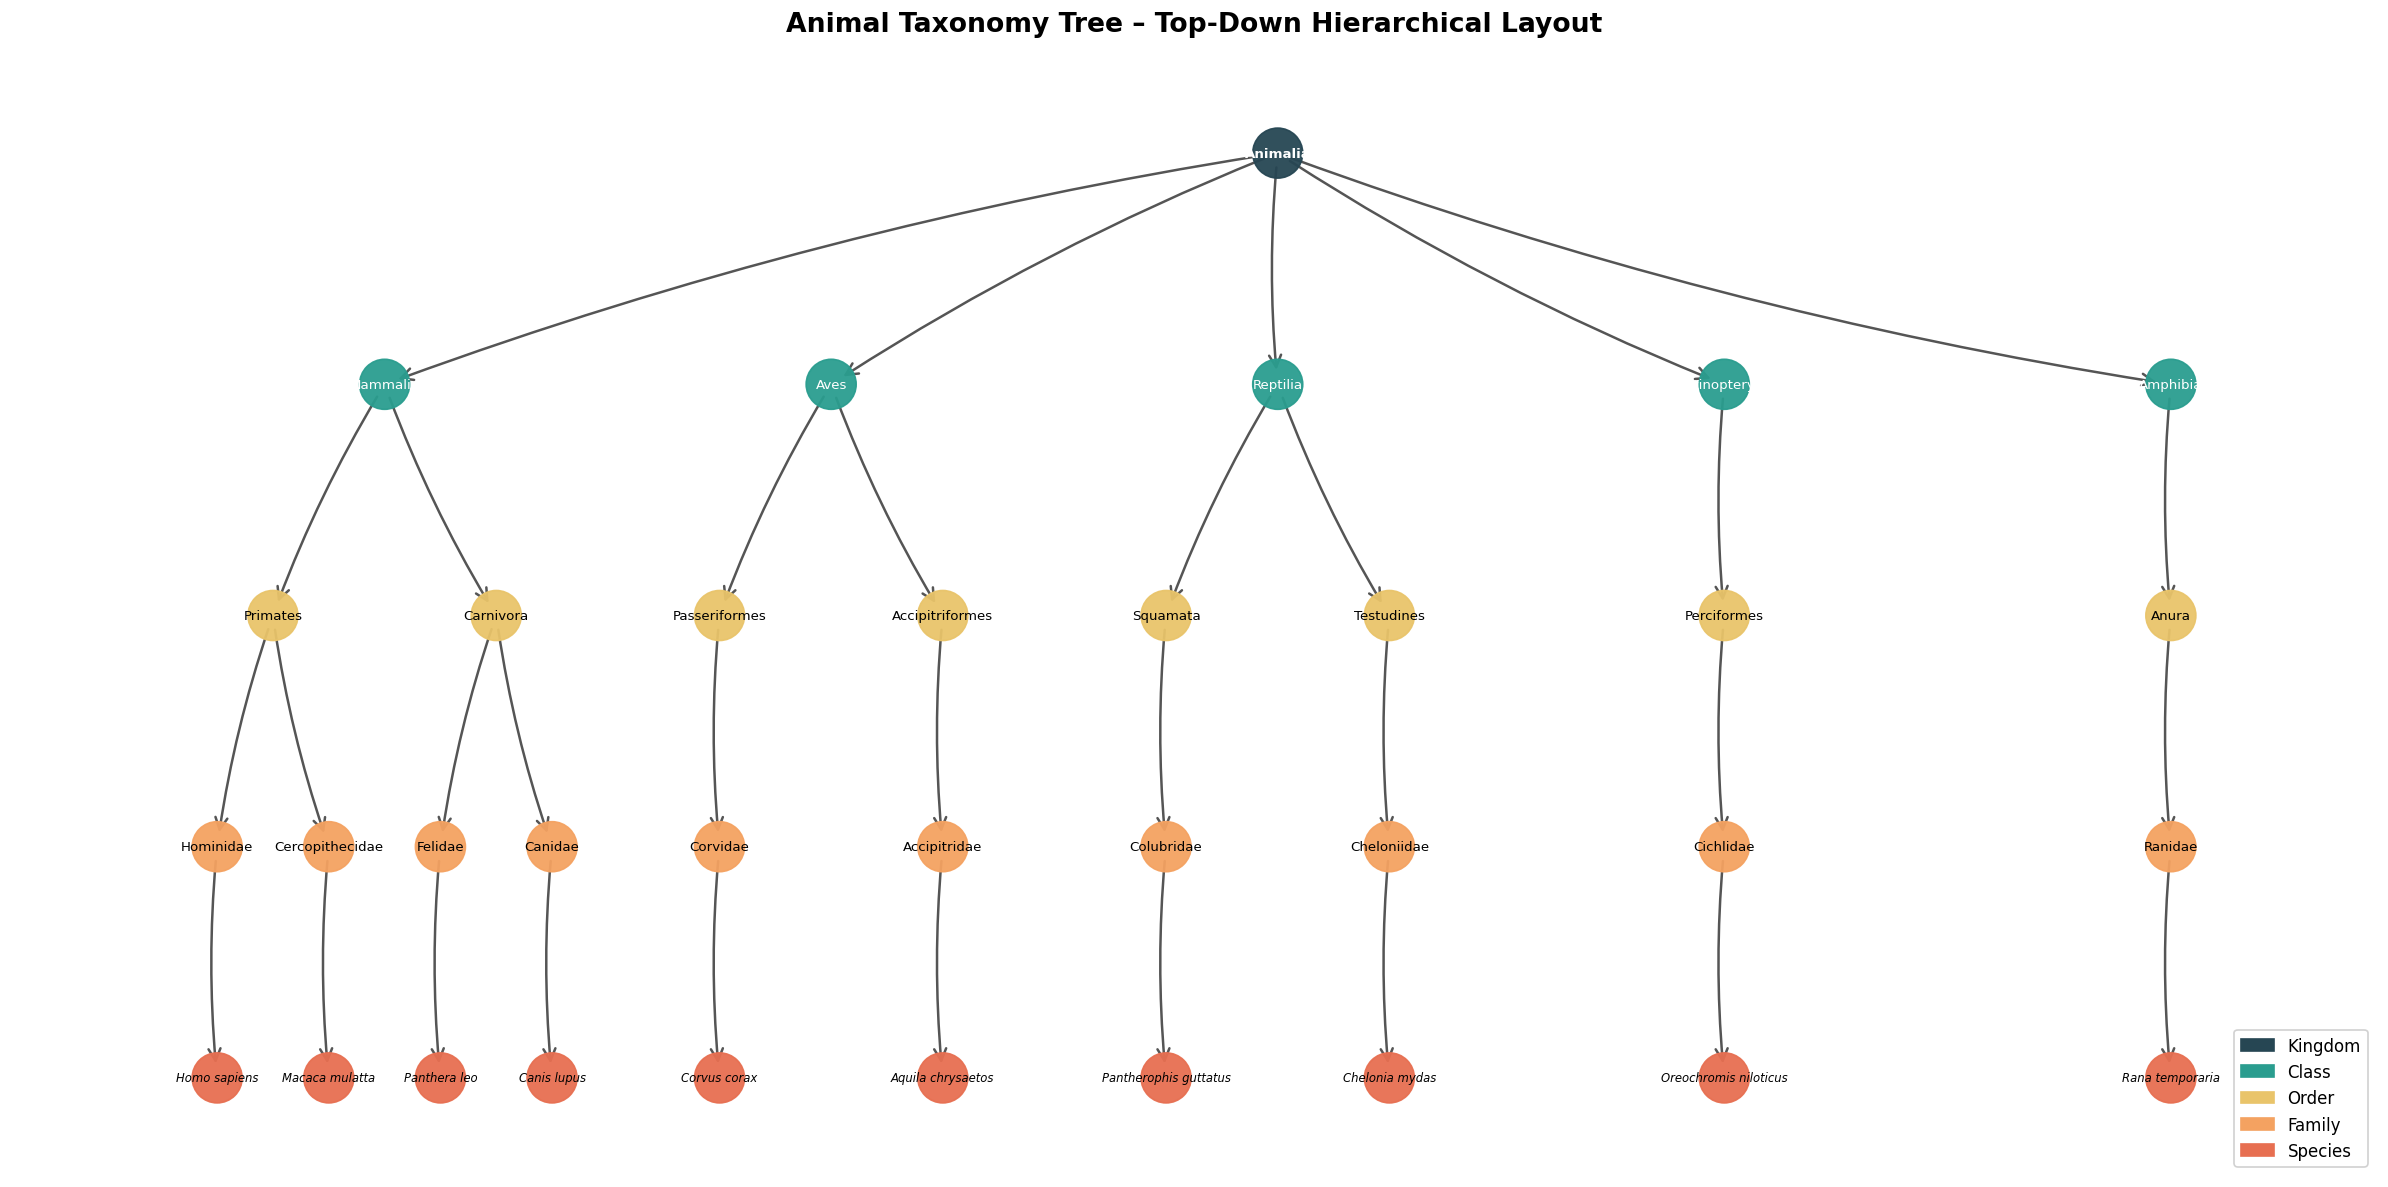

Figure saved → tree_hierarchical.png


In [6]:
fig, ax = plt.subplots(figsize=(20, 10))

pos_hier = hierarchy_pos(T, "Animalia", width=1.0, vert_gap=0.18)

nx.draw_networkx_nodes(T, pos_hier, node_color=node_colors, node_size=900, ax=ax, alpha=0.95)
nx.draw_networkx_edges(T, pos_hier, ax=ax, arrows=True,
                       arrowstyle="->", arrowsize=18,
                       edge_color="#555555", width=1.5,
                       connectionstyle="arc3,rad=0.05")

# Italic for species (level 4), normal for the rest
for node, (x, y) in pos_hier.items():
    style = 'italic' if levels[node] == 4 else 'normal'
    fontsize = 7 if levels[node] == 4 else 8
    ax.text(x, y, node, ha='center', va='center',
            fontsize=fontsize, fontstyle=style,
            fontweight='bold' if levels[node] == 0 else 'normal',
            color='white' if levels[node] in (0, 1) else 'black',
            wrap=True)

ax.legend(handles=legend_patches, loc='lower right', fontsize=10, framealpha=0.9)
ax.set_title("Animal Taxonomy Tree – Top-Down Hierarchical Layout",
             fontsize=16, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig("tree_hierarchical.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → tree_hierarchical.png")

### 1.3 Tree Layout 2 – Radial (Circular) Layout

The **radial layout** places the root at the centre and fans children outward in concentric rings. Each ring corresponds to a taxonomic level. This layout is compact and highlights the **branching symmetry** of the hierarchy, making it easy to compare how many children each class or order has.

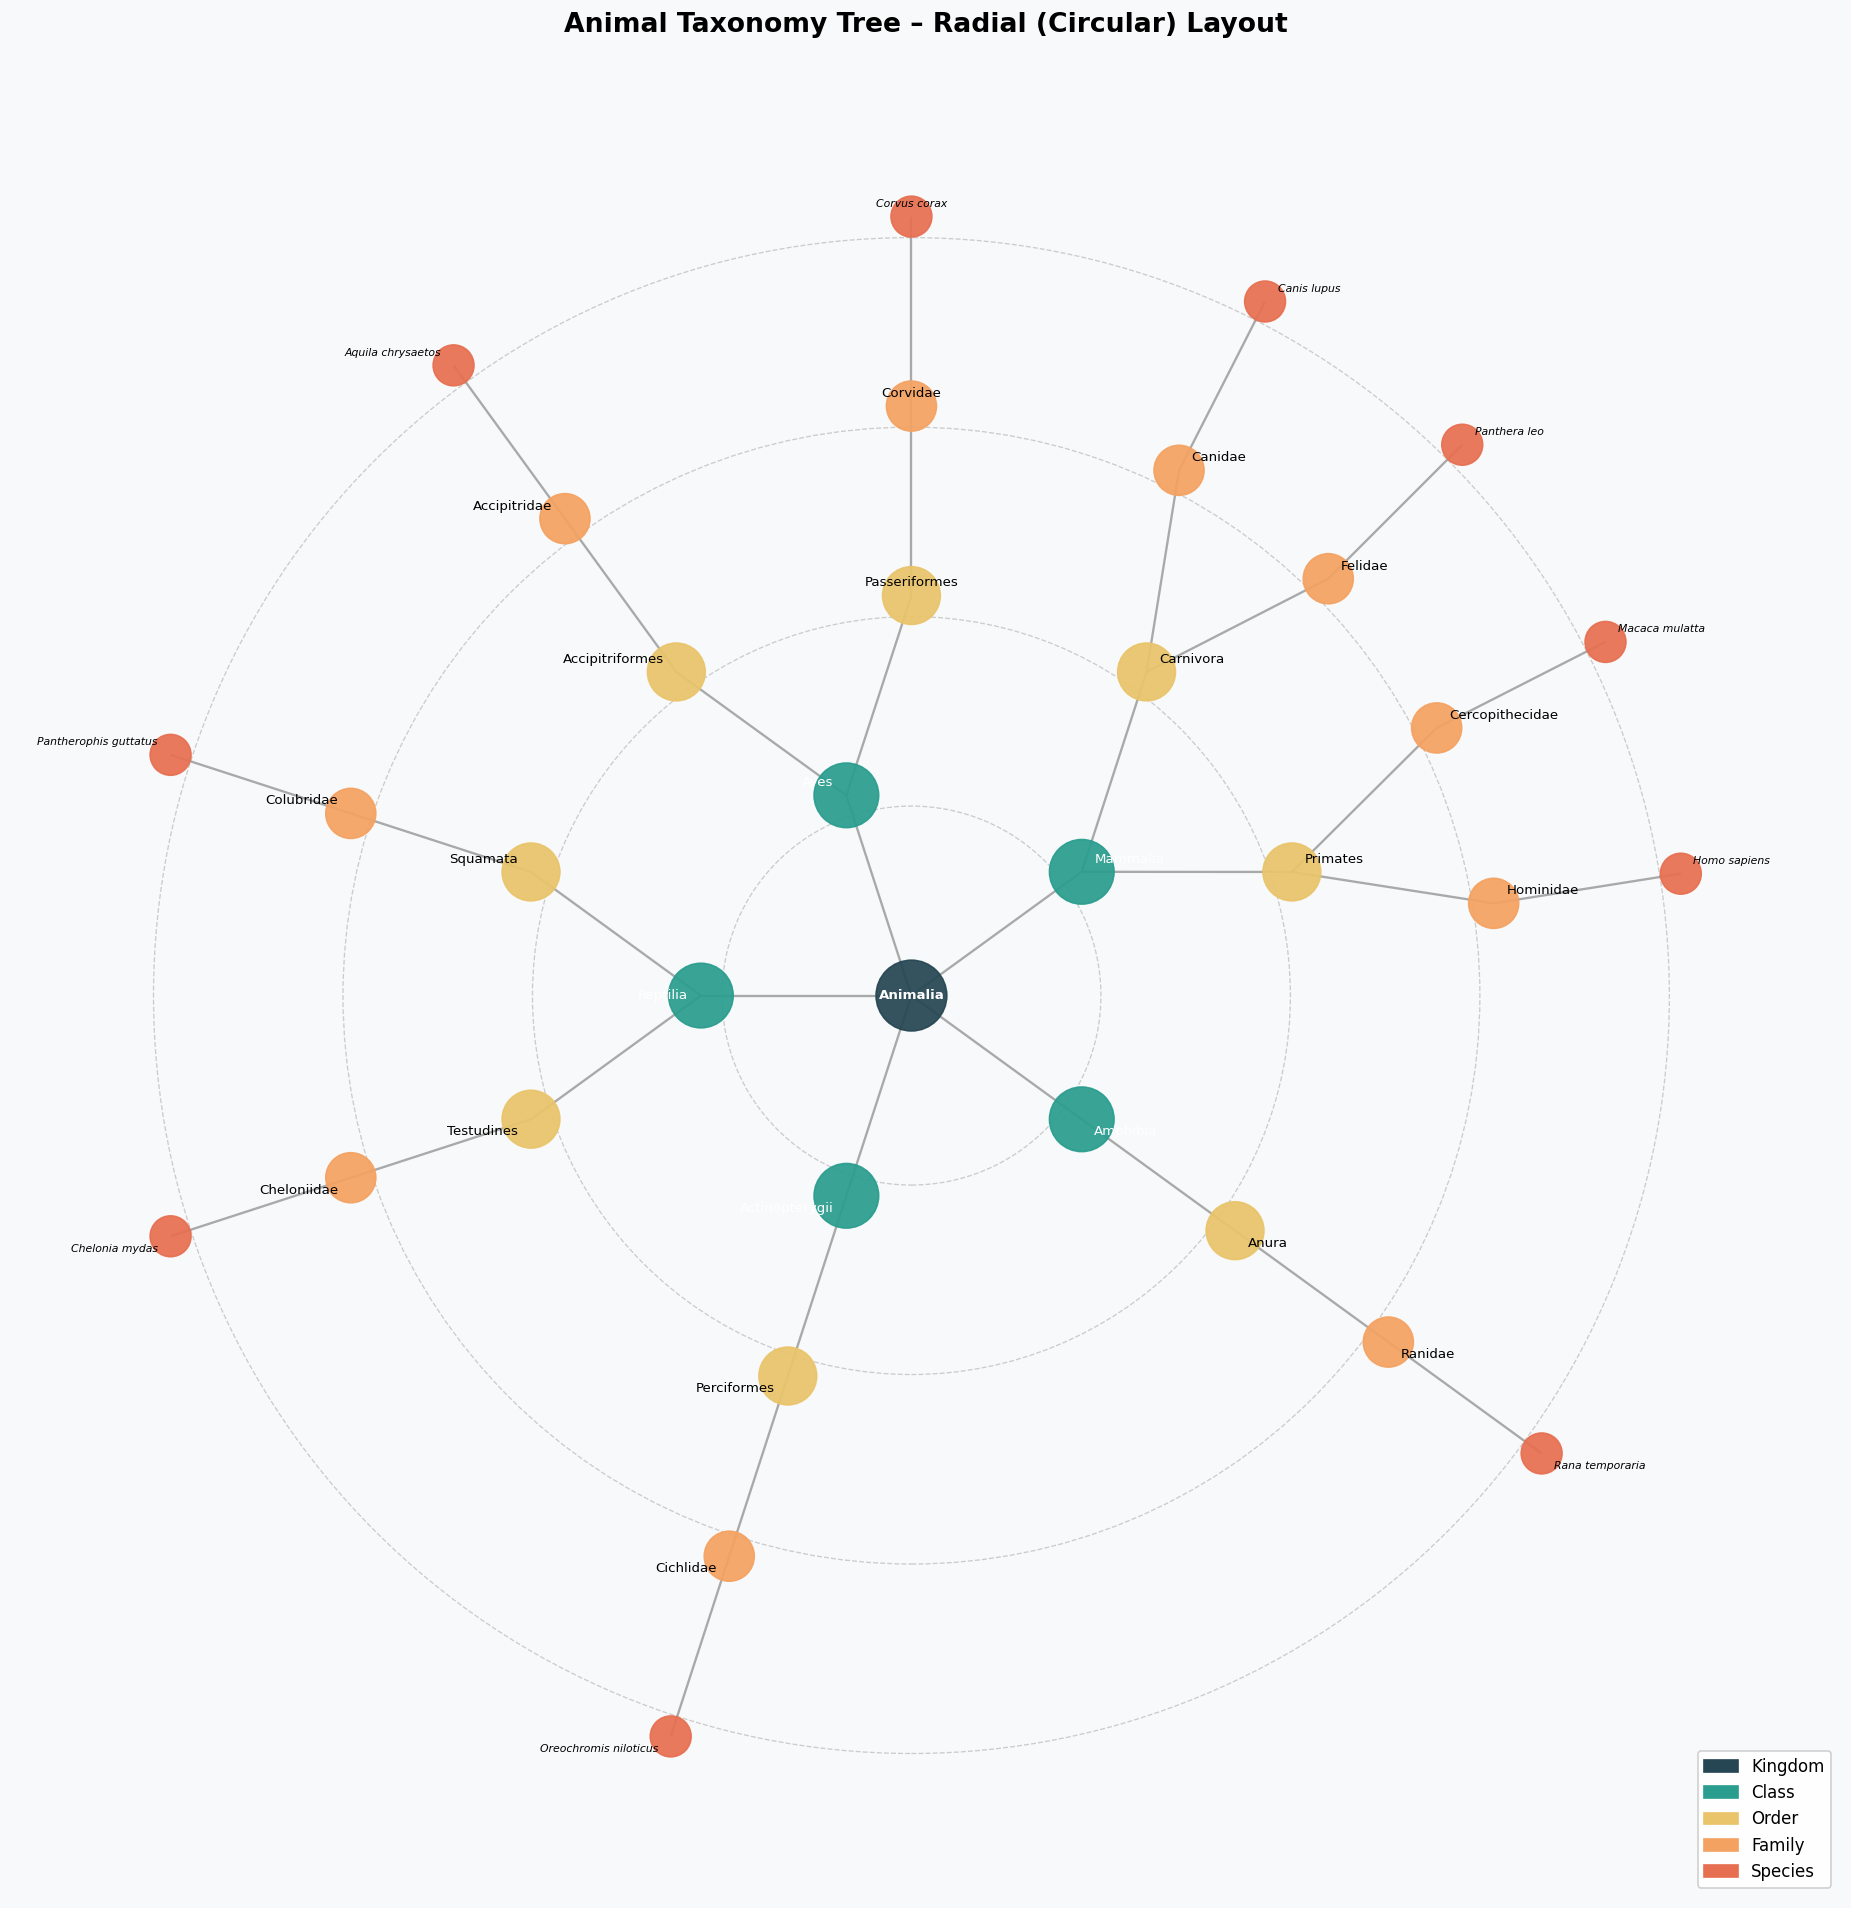

Figure saved → tree_radial.png


In [7]:
def radial_tree_pos(G, root):
    """Place root at origin; children on expanding rings by BFS level."""
    pos = {root: np.array([0.0, 0.0])}
    visited = {root}
    queue = deque([(root, 0.0, 2 * np.pi, 1)])  # node, angle_start, angle_end, radius

    while queue:
        node, a_start, a_end, r = queue.popleft()
        children = [c for c in G.successors(node) if c not in visited]
        if not children:
            continue
        step = (a_end - a_start) / len(children)
        for i, child in enumerate(children):
            angle = a_start + (i + 0.5) * step
            pos[child] = np.array([r * np.cos(angle), r * np.sin(angle)])
            visited.add(child)
            queue.append((child, a_start + i * step, a_start + (i + 1) * step, r + 0.9))
    return pos

pos_radial = radial_tree_pos(T, "Animalia")

fig, ax = plt.subplots(figsize=(16, 16))
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

# Draw concentric guide circles
for r in [0.9, 1.8, 2.7, 3.6]:
    circle = plt.Circle((0, 0), r, color='#cccccc', fill=False, linewidth=0.8, linestyle='--')
    ax.add_patch(circle)

# Compute node sizes: root biggest, leaves smallest
sizes = [1800 - levels[n] * 300 for n in T.nodes()]

nx.draw_networkx_nodes(T, pos_radial, node_color=node_colors,
                       node_size=sizes, ax=ax, alpha=0.93)
nx.draw_networkx_edges(T, pos_radial, ax=ax, arrows=False,
                       edge_color="#888888", width=1.4, alpha=0.7)

for node, (x, y) in pos_radial.items():
    lv = levels[node]
    style = 'italic' if lv == 4 else 'normal'
    fontsize = 6.5 if lv == 4 else 8
    ha = 'left' if x > 0.1 else ('right' if x < -0.1 else 'center')
    offset_x = 0.06 * np.sign(x) if abs(x) > 0.1 else 0
    offset_y = 0.06 * np.sign(y) if abs(y) > 0.1 else 0
    ax.text(x + offset_x, y + offset_y, node,
            ha=ha, va='center', fontsize=fontsize,
            fontstyle=style,
            fontweight='bold' if lv == 0 else 'normal',
            color='white' if lv in (0, 1) else 'black')

ax.legend(handles=legend_patches, loc='lower right', fontsize=10, framealpha=0.9)
ax.set_title("Animal Taxonomy Tree – Radial (Circular) Layout",
             fontsize=16, fontweight='bold', pad=15)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.savefig("tree_radial.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → tree_radial.png")

---
## 2. Dataset 2 – Zachary's Karate Club Network

### 2.1 Dataset Description

| Attribute | Detail |
|-----------|--------|
| **Source** | W. W. Zachary (1977). *An information flow model for conflict and fission in small groups.* Journal of Anthropological Research, 33(4), 452–473. Built into NetworkX: `nx.karate_club_graph()` |
| **Type** | Undirected, unweighted simple graph |
| **Nodes** | 34 members of a university karate club |
| **Edges** | 78 edges; an edge between two members indicates **social interaction outside the club** (friendship ties) |
| **Why ideal for a graph?** | It contains **cycles**, **multiple communities**, and **hub nodes** – features that are impossible in a tree and make it a classic benchmark for graph layout and community detection algorithms |

The dataset is famous because the club split into two factions (instructor vs. administrator) which can be recovered purely from the network structure.

In [8]:
# ── Load the Karate Club graph ────────────────────────────────────────────────
G = nx.karate_club_graph()

print(f"Nodes  : {G.number_of_nodes()}")
print(f"Edges  : {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
print(f"Avg degree: {sum(d for _, d in G.degree()) / G.number_of_nodes():.2f}")

# Community label from the dataset attribute (ground-truth faction)
clubs = nx.get_node_attributes(G, 'club')  # 'Mr. Hi' or 'Officer'
community_color = ["#e63946" if clubs[n] == 'Mr. Hi' else "#457b9d" for n in G.nodes()]

# Node size proportional to degree (hubs appear larger)
degrees = dict(G.degree())
node_sizes = [200 + degrees[n] * 60 for n in G.nodes()]

# Legend
legend_patches_g = [
    mpatches.Patch(color="#e63946", label="Faction: Mr. Hi (instructor)"),
    mpatches.Patch(color="#457b9d", label="Faction: Officer (administrator)"),
]
print("Graph loaded ✓")

Nodes  : 34
Edges  : 78
Density: 0.1390
Avg degree: 4.59
Graph loaded ✓


### 2.2 Graph Layout 1 – Spring (Force-Directed) Layout

The **Fruchterman-Reingold force-directed layout** simulates physical forces: nodes repel each other like charged particles while edges act as springs pulling connected nodes together. The result is an organic layout that naturally **clusters tightly-connected communities** and minimises edge crossings. The two factions of the karate club emerge visually without any explicit community detection.

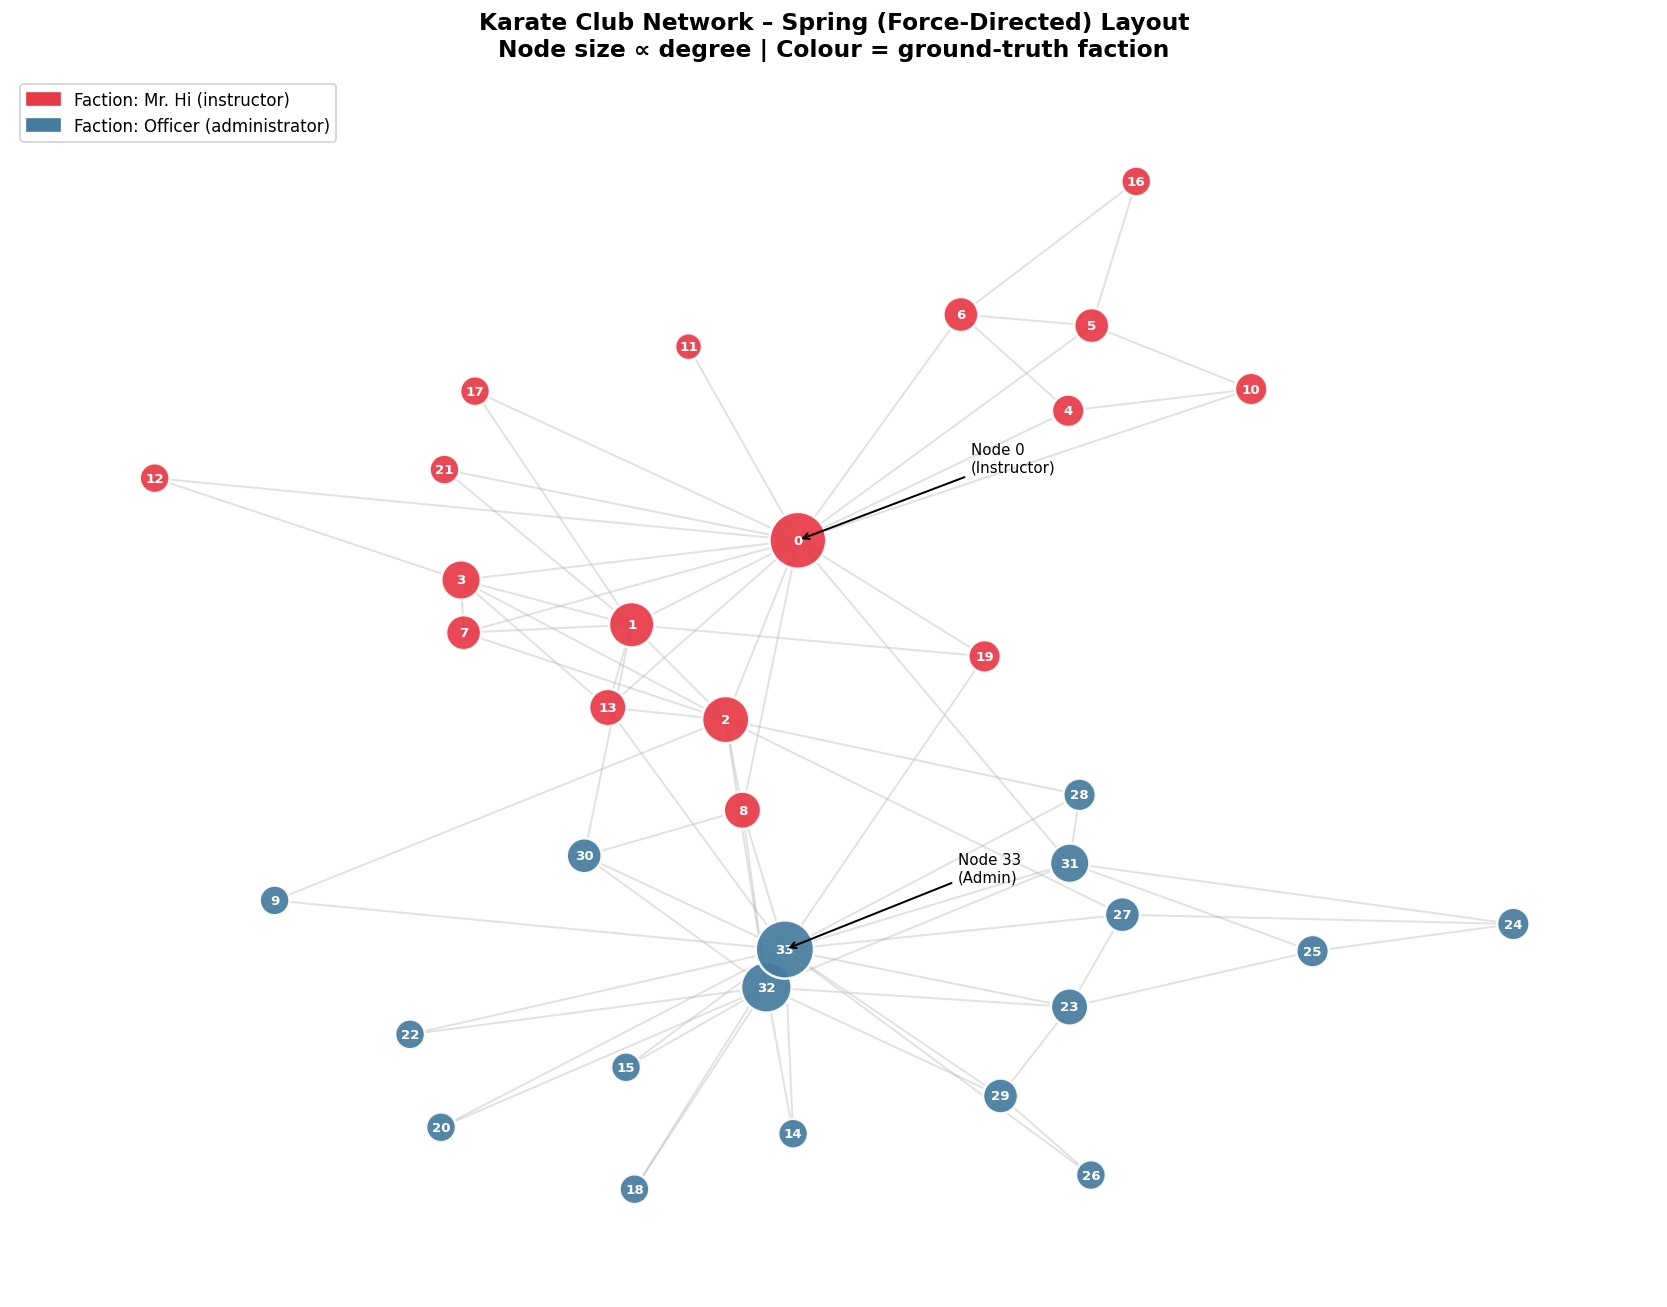

Figure saved → graph_spring.png


In [9]:
fig, ax = plt.subplots(figsize=(14, 11))

pos_spring = nx.spring_layout(G, seed=42, k=0.55, iterations=100)

nx.draw_networkx_edges(G, pos_spring, ax=ax, alpha=0.35,
                       edge_color="#aaaaaa", width=1.2)
nx.draw_networkx_nodes(G, pos_spring, node_color=community_color,
                       node_size=node_sizes, ax=ax, alpha=0.92,
                       linewidths=1.5, edgecolors='white')
nx.draw_networkx_labels(G, pos_spring, ax=ax, font_size=8,
                        font_color='white', font_weight='bold')

# Annotate hub nodes
for hub, label in [(0, "Node 0\n(Instructor)"), (33, "Node 33\n(Admin)")]:
    x, y = pos_spring[hub]
    ax.annotate(label, xy=(x, y), xytext=(x + 0.12, y + 0.12),
                fontsize=9, color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax.legend(handles=legend_patches_g, loc='upper left', fontsize=10, framealpha=0.9)
ax.set_title("Karate Club Network – Spring (Force-Directed) Layout\n"
             "Node size ∝ degree | Colour = ground-truth faction",
             fontsize=14, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.savefig("graph_spring.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → graph_spring.png")

### 2.3 Graph Layout 2 – Kamada-Kawai Layout

The **Kamada-Kawai layout** minimises the difference between the Euclidean distance of nodes in the drawing and their **shortest-path (graph-theoretic) distance**. Nodes that are topologically close in the network are placed close together in the plane. Compared to the spring layout, Kamada-Kawai produces a more **geometrically regular** arrangement and more clearly reveals the structural roles of bridge nodes that connect the two factions.

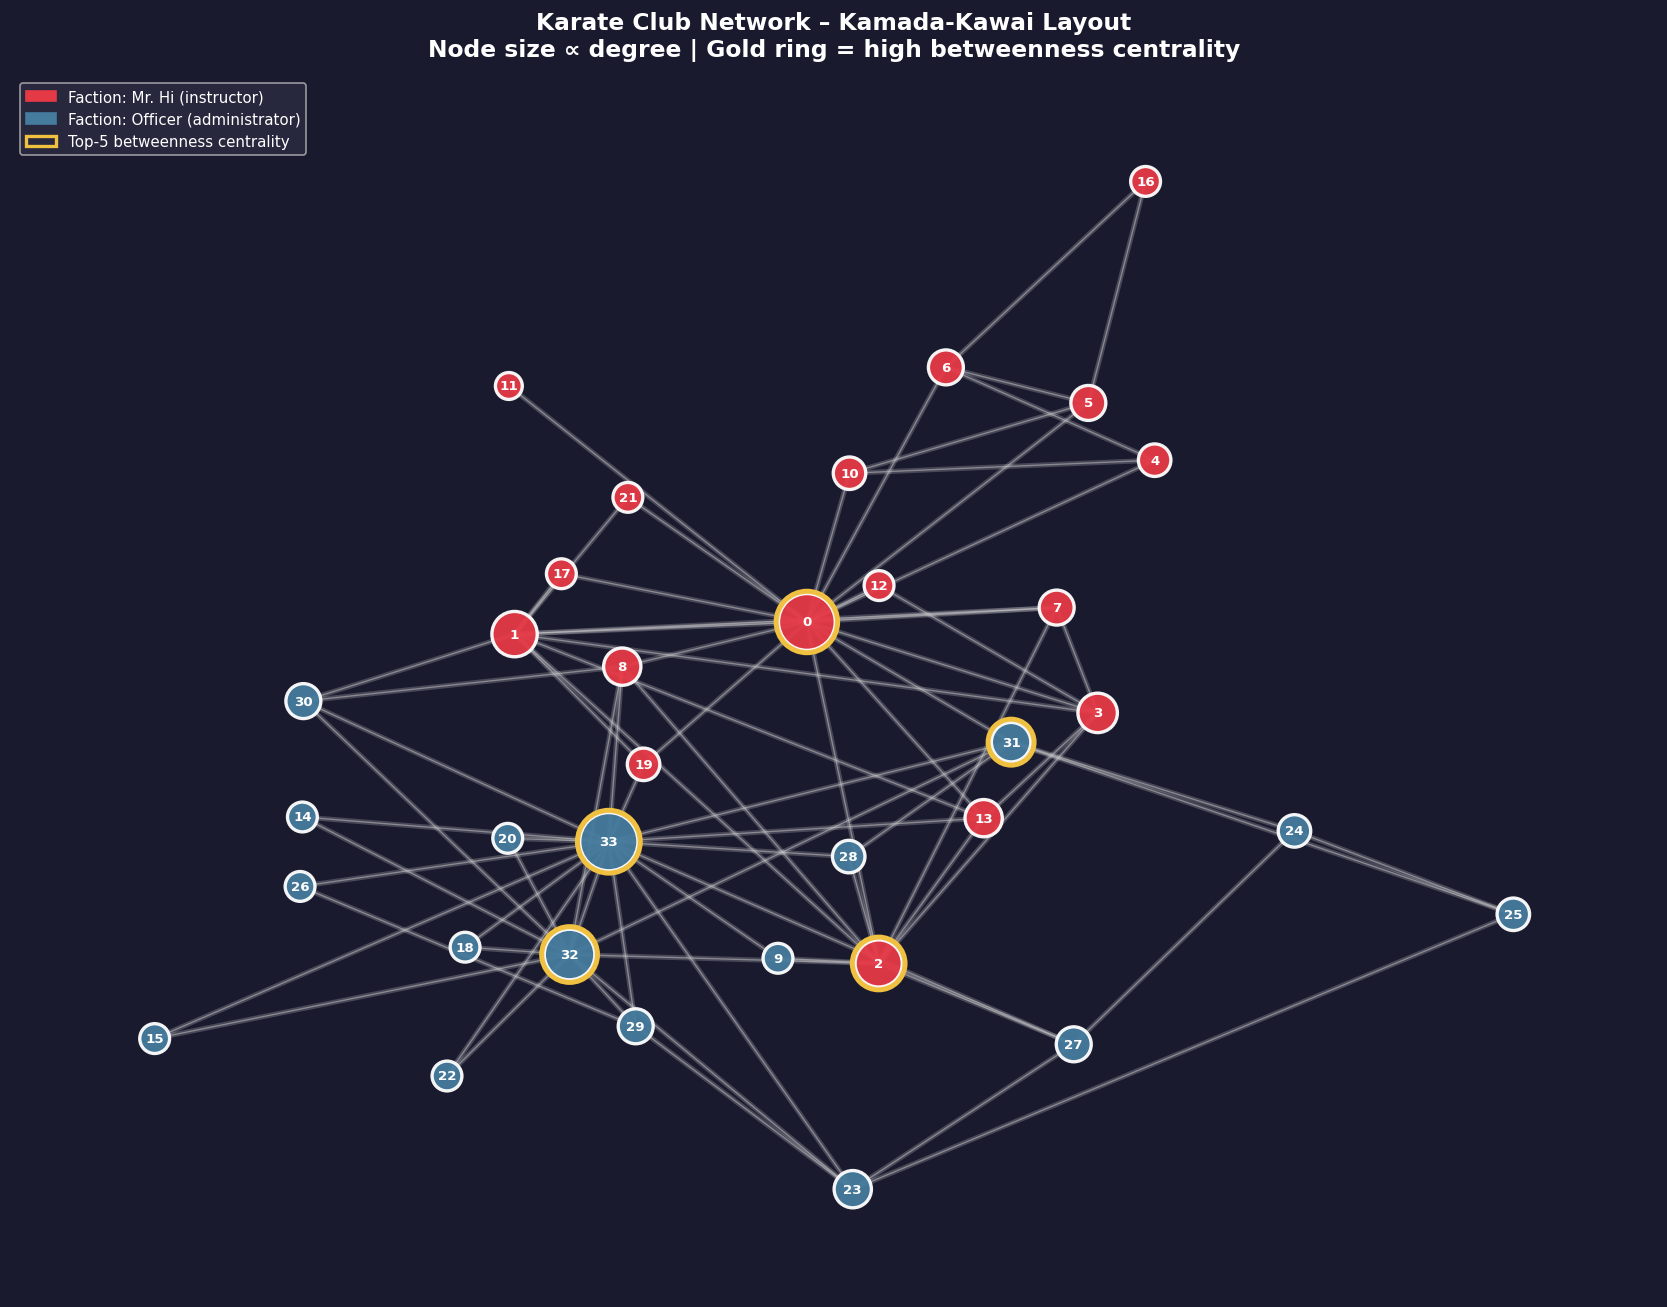

Figure saved → graph_kamada_kawai.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 11))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#1a1a2e")

pos_kk = nx.kamada_kawai_layout(G)

# Draw edges with gradient-like effect using thin + thick layers
nx.draw_networkx_edges(G, pos_kk, ax=ax, alpha=0.2,
                       edge_color="#ffffff", width=3)
nx.draw_networkx_edges(G, pos_kk, ax=ax, alpha=0.5,
                       edge_color="#cccccc", width=0.8)

nx.draw_networkx_nodes(G, pos_kk, node_color=community_color,
                       node_size=node_sizes, ax=ax, alpha=0.95,
                       linewidths=2, edgecolors='white')
nx.draw_networkx_labels(G, pos_kk, ax=ax, font_size=8,
                        font_color='white', font_weight='bold')

# Highlight bridge nodes (betweenness centrality top-5)
betweenness = nx.betweenness_centrality(G)
top5 = sorted(betweenness, key=betweenness.get, reverse=True)[:5]
nx.draw_networkx_nodes(G, pos_kk, nodelist=top5,
                       node_color='none', node_size=[node_sizes[n] + 200 for n in top5],
                       ax=ax, linewidths=3, edgecolors='#f0c040')

legend_patches_kk = legend_patches_g + [
    mpatches.Patch(edgecolor='#f0c040', facecolor='none',
                   linewidth=2, label='Top-5 betweenness centrality')
]
ax.legend(handles=legend_patches_kk, loc='upper left', fontsize=9,
          framealpha=0.7, facecolor='#2d2d44', labelcolor='white')
ax.set_title("Karate Club Network – Kamada-Kawai Layout\n"
             "Node size ∝ degree | Gold ring = high betweenness centrality",
             fontsize=14, fontweight='bold', pad=12, color='white')
ax.axis('off')
plt.tight_layout()
plt.savefig("graph_kamada_kawai.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → graph_kamada_kawai.png")

---
## 3. Summary & Comparison

### 3.1 Tree Dataset Layouts

| Layout | Strengths | Best Used When |
|--------|-----------|----------------|
| **Top-Down Hierarchical** | Clear parent–child relationships; easy to read level-by-level | Explaining a chain of command, org charts, taxonomies with few levels |
| **Radial** | Compact; shows branching symmetry; saves horizontal space | Deep trees with many leaves; comparing breadth of subtrees |

### 3.2 Graph Dataset Layouts

| Layout | Strengths | Best Used When |
|--------|-----------|----------------|
| **Spring (Fruchterman-Reingold)** | Organic clustering; reveals communities naturally; minimises edge crossings | Community detection, social networks, exploratory analysis |
| **Kamada-Kawai** | Geometrically faithful to graph distances; highlights bridge nodes; globally optimal | Structural analysis, identifying cut vertices, comparing node centrality |

### 3.3 Key Observations

- **Tree**: The hierarchical layout makes the taxonomic levels explicit (Kingdom at top, Species at bottom). The radial layout compactly shows that *Mammalia* has the most branching.
- **Graph**: Both layouts reveal the two factions (red vs blue) and identify **Node 0** (instructor) and **Node 33** (administrator) as the dominant hubs. The Kamada-Kawai layout additionally highlights the **bridge nodes** (gold rings) that connect the two communities – exactly the members who were friends with both factions before the split.

In [ ]:
# ── Quick stats summary ───────────────────────────────────────────────────────
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"\nDataset 1 – Animal Taxonomy Tree")
print(f"  Nodes  : {T.number_of_nodes()}")
print(f"  Edges  : {T.number_of_edges()}")
print(f"  Depth  : {max(levels.values())}")
print(f"  Leaves : {sum(1 for n in T.nodes() if T.out_degree(n) == 0)}")

print(f"\nDataset 2 – Karate Club Network")
print(f"  Nodes  : {G.number_of_nodes()}")
print(f"  Edges  : {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.4f}")
print(f"  Avg clustering: {nx.average_clustering(G):.4f}")
print(f"  Diameter: {nx.diameter(G)}")
print(f"  Top-3 degree nodes: {sorted(G.degree(), key=lambda x: x[1], reverse=True)[:3]}")
print("=" * 50)

DATASET SUMMARY

Dataset 1 – Animal Taxonomy Tree
  Nodes  : 34
  Edges  : 33
  Depth  : 4
  Leaves : 10

Dataset 2 – Karate Club Network
  Nodes  : 34
  Edges  : 78
  Density: 0.1390
  Avg clustering: 0.5706
  Diameter: 5
  Top-3 degree nodes: [(33, 17), (0, 16), (32, 12)]
